In [6]:
# Cell 1: Import libraries and load data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("✅ Libraries imported")

# -----------------------------------
# Load Energy Efficiency dataset
# -----------------------------------

print("📥 Loading Energy Efficiency dataset...")

try:
    
    # Load dataset from OpenML
    data = fetch_openml(
        name="Energy-efficiency",
        version=1,
        as_frame=True
    )
    
    df = data.frame
    
    print("✅ Dataset loaded successfully!")
    print(f"   Shape: {df.shape}")
    
    print("\n📋 Dataset columns:")
    print(df.columns)

except Exception as e:
    
    print("⚠️ Download failed")
    print(e)

# -----------------------------------
# Prepare features and target
# -----------------------------------

# Automatically detect heating-load column
if 'Y1' in df.columns:
    target_col = 'Y1'
elif 'y1' in df.columns:
    target_col = 'y1'
else:
    raise ValueError("Heating load column not found!")

# Remove target columns from features
feature_cols = [
    col for col in df.columns
    if col not in ['Y1', 'Y2', 'y1', 'y2']
]

# Extract features
X = df[feature_cols].values

# Convert target to numeric
y = pd.to_numeric(df[target_col]).values

# -----------------------------------
# Train-test split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Standardize features
# -----------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------
# Dataset information
# -----------------------------------

print(f"\n📊 Data split:")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples: {X_test.shape[0]}")
print(f"   Number of features: {X.shape[1]}")
print(f"   Target range: {y.min():.2f} to {y.max():.2f}")

print("\n✅ Data preprocessing complete!")

✅ Libraries imported
📥 Loading Energy Efficiency dataset...
✅ Dataset loaded successfully!
   Shape: (768, 10)

📋 Dataset columns:
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'y1', 'y2'], dtype='object')

📊 Data split:
   Training samples: 614
   Testing samples: 154
   Number of features: 8
   Target range: 1.00 to 37.00

✅ Data preprocessing complete!


In [7]:
# Cell 2: Linear Regression using Gradient Descent (from scratch)
class LinearRegressionGD:
    """Linear Regression implemented with Gradient Descent"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=True):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def predict(self, X):
        """Make predictions: y = X·w + b"""
        return np.dot(X, self.weights) + self.bias
    
    def compute_loss(self, X, y):
        """Mean Squared Error loss"""
        y_pred = self.predict(X)
        m = len(y)
        return (1/(2*m)) * np.sum((y_pred - y)**2)
    
    def compute_gradients(self, X, y):
        """Calculate gradients for weights and bias"""
        m = len(y)
        y_pred = self.predict(X)
        
        # Gradient for weights: (1/m) * X^T · (y_pred - y)
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        
        # Gradient for bias: (1/m) * sum(y_pred - y)
        db = (1/m) * np.sum(y_pred - y)
        
        return dw, db
    
    def fit(self, X, y):
        """Train the model using gradient descent"""
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []
        
        # Gradient descent loop
        for i in range(self.n_iterations):
            # Compute gradients
            dw, db = self.compute_gradients(X, y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Record loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            
            # Print progress
            if self.verbose and (i + 1) % 200 == 0:
                print(f"  Iteration {i+1}/{self.n_iterations}: Loss = {loss:.6f}")
        
        return self
    
    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        
        # Total sum of squares
        ss_tot = np.sum((y - np.mean(y))**2)
        
        # Residual sum of squares
        ss_res = np.sum((y - y_pred)**2)
        
        # R² = 1 - (SS_res / SS_tot)
        r2 = 1 - (ss_res / ss_tot)
        
        return r2

print("✅ LinearRegressionGD class defined")

✅ LinearRegressionGD class defined



📊 Training with learning_rate=0.001
  Iteration 200/500: Loss = 91.223257
  Iteration 400/500: Loss = 64.894761

📊 Training with learning_rate=0.01
  Iteration 200/500: Loss = 20.461134
  Iteration 400/500: Loss = 18.553877

📊 Training with learning_rate=0.05
  Iteration 200/500: Loss = 18.171881
  Iteration 400/500: Loss = 17.906399

📊 Training with learning_rate=0.1
  Iteration 200/500: Loss = 17.906020
  Iteration 400/500: Loss = 17.765587


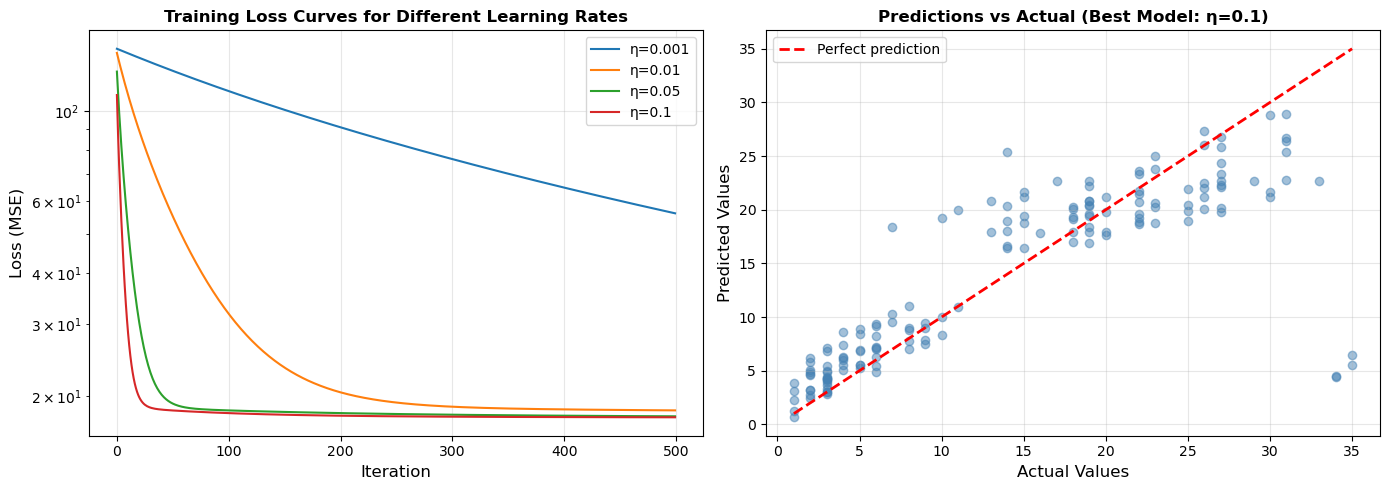


✅ Best model: learning_rate=0.1
   Final training loss: 17.745859
   Test loss: 17.605792


In [8]:
# Cell 3: Train linear regression model
# Try different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1]
models = {}
losses = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in learning_rates:
    print(f"\n📊 Training with learning_rate={lr}")
    model = LinearRegressionGD(learning_rate=lr, n_iterations=500, verbose=True)
    model.fit(X_train_scaled, y_train)
    models[lr] = model
    
    # Plot loss curve
    axes[0].plot(model.loss_history, label=f'η={lr}', linewidth=1.5)

# Find best model (lowest test loss)
best_lr = min(learning_rates, key=lambda lr: models[lr].compute_loss(X_test_scaled, y_test))
best_model = models[best_lr]

axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Curves for Different Learning Rates', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Prediction vs Actual plot
y_pred = best_model.predict(X_test_scaled)
axes[1].scatter(y_test, y_pred, alpha=0.5, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Values', fontsize=12)
axes[1].set_ylabel('Predicted Values', fontsize=12)
axes[1].set_title(f'Predictions vs Actual (Best Model: η={best_lr})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Best model: learning_rate={best_lr}")
print(f"   Final training loss: {best_model.loss_history[-1]:.6f}")
print(f"   Test loss: {best_model.compute_loss(X_test_scaled, y_test):.6f}")


📈 LINEAR REGRESSION FINAL REPORT

🎯 BEST MODEL (η=0.1):
   Training R²:  0.641125
   Testing R²:   0.647961
   Training MSE: 17.745859
   Testing MSE:  17.605792

📐 LEARNED PARAMETERS:
   Bias: 13.6189
   Weights (first 5):
      V1: -3.1818
      V2: -1.3916
      V3: 1.1959
      V4: -1.9407
      V5: 6.7389


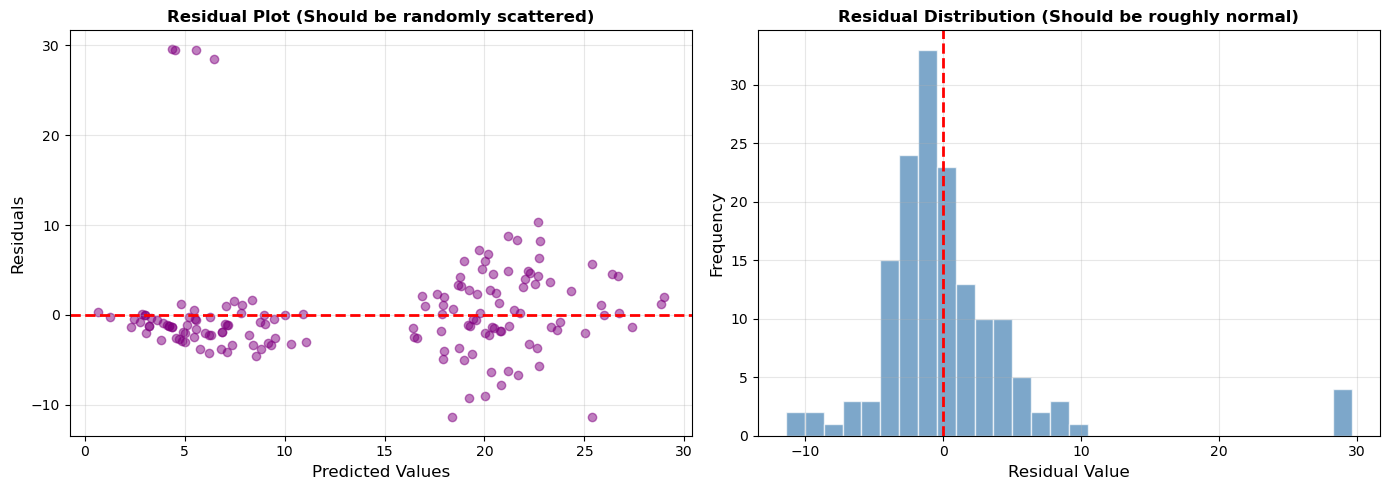


💡 INTERPRETATION:
   ✓ Model generalizes well (no significant overfitting)
   ⚠️ Residuals show systematic bias

🎉 Project Complete! You've implemented Linear Regression from scratch!


In [9]:
# Cell 5: Generate final report
print("\n" + "="*70)
print("📈 LINEAR REGRESSION FINAL REPORT")
print("="*70)

# Multi-feature model evaluation
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)

train_r2 = best_model.score(X_train_scaled, y_train)
test_r2 = best_model.score(X_test_scaled, y_test)

train_mse = best_model.compute_loss(X_train_scaled, y_train)
test_mse = best_model.compute_loss(X_test_scaled, y_test)

print(f"\n🎯 BEST MODEL (η={best_lr}):")
print(f"   Training R²:  {train_r2:.6f}")
print(f"   Testing R²:   {test_r2:.6f}")
print(f"   Training MSE: {train_mse:.6f}")
print(f"   Testing MSE:  {test_mse:.6f}")

print(f"\n📐 LEARNED PARAMETERS:")
print(f"   Bias: {best_model.bias:.4f}")
print(f"   Weights (first 5):")
for i in range(min(5, len(best_model.weights))):
    print(f"      {feature_cols[i]}: {best_model.weights[i]:.4f}")

# Residual analysis
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_pred_test, residuals, alpha=0.5, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residual Plot (Should be randomly scattered)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Residual Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution (Should be roughly normal)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
if abs(train_r2 - test_r2) < 0.1:
    print("   ✓ Model generalizes well (no significant overfitting)")
else:
    print("   ⚠️ Potential overfitting (difference in R² scores)")

if np.mean(residuals) < 0.1:
    print("   ✓ Residuals centered near zero (good bias)")
else:
    print("   ⚠️ Residuals show systematic bias")

print("\n🎉 Project Complete! You've implemented Linear Regression from scratch!")